# SNR Segment Check
Compare `ml4gw.compute_network_snr` computed over different time windows against the stored SNR in the h5 file.

Data: 256 Hz, 64 s, coalescence at 63 s.

**Note on expected SNR ratio:** The stored SNR was computed *before* downsampling, at the original **4096 Hz** sample rate (covering 20–2048 Hz). The h5 file stores data at **256 Hz** (covering 20–128 Hz). The fraction of BNS SNR² contained below 128 Hz is typically ~40–65%, so `computed / stored ≈ 0.6–0.8` is physically expected—not a bug.

In [1]:
import h5py
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from ml4gw.gw import compute_network_snr
from ml4gw.transforms import SpectralDensity

%matplotlib inline

H5_PATH     = "/n/holystore01/LABS/iaifi_lab/Lab/kyoon/DATA/ai4gw@cern/bns_snr_5_50_uniform_powerlaw_256Hz_100K/test/sig_combined_test.h5"
SAMPLE_RATE = 256          # Hz
F_MIN       = 20.0         # Hz — highpass, matches generation config
FFTLENGTH   = 2.0          # sec — matches whiten.fftlength in generation config
AVERAGE     = 'median'     # matches whiten.average in generation config
N_EVENTS    = 500          # events to process (set None for all 10000)
BATCH_SIZE  = 128

# Time windows (start_s, end_s, label)
WINDOWS = [
    (0,  64, "0–64 s  (full segment)"),
    (59, 64, "59–64 s (5 s incl. merger)"),
    (0,  55, "0–55 s  (pre-merger)"),
    (63, 64, "63–64 s (1 s merger)"),
]

with h5py.File(H5_PATH, 'r') as f:
    n_total, n_ch, n_samp = f['raw_signal'].shape
print(f"Events: {n_total}  |  Channels: {n_ch}  |  Samples: {n_samp}  ({n_samp/SAMPLE_RATE:.0f} s @ {SAMPLE_RATE} Hz)")

# SpectralDensity matches exactly what injections.py uses:
#   psd = spectral_density(background_samples[..., :psd_size].double())
# fftlength=2s → window 512 samples → 257 frequency bins
spectral_density = SpectralDensity(
    sample_rate=SAMPLE_RATE,
    fftlength=FFTLENGTH,
    average=AVERAGE,
)
print(f"SpectralDensity: fftlength={FFTLENGTH}s  →  {int(FFTLENGTH*SAMPLE_RATE)//2+1} freq bins")

Events: 10000  |  Channels: 2  |  Samples: 16384  (64 s @ 256 Hz)
SpectralDensity: fftlength=2.0s  →  257 freq bins


In [2]:
def compute_segment_snr(h5_path, start_s, end_s, n_events=None, n_psd_events=500):
    """
    Mirrors injections.py lines 83 / 100 / 119:
      psd         = spectral_density(background)
      psd         = F.interpolate(psd, size=(num_freqs,), mode='linear')
      network_snr = compute_network_snr(responses, psd, sample_rate, highpass)

    The generation code uses raw (unwhitened) signal + PSD — not whitened data.
    compute_network_snr computes 4∫|h(f)|²/S(f)df, which needs both separately.

    NOTE: the stored data is downsampled to 256 Hz (Nyquist = 128 Hz).  The
    stored SNR was computed at the original 4096 Hz rate, so it includes signal
    power up to 2048 Hz.  The SNR computed here only covers 20–128 Hz, so
    computed / stored ≈ 0.6–0.8 is expected.

    PSD is averaged over n_psd_events background draws to reduce per-event
    variance and converge toward the true detector PSD.

    Returns (snr_computed, snr_stored), both shape (n_events,).
    """
    start_sample = int(start_s * SAMPLE_RATE)
    end_sample   = int(end_s   * SAMPLE_RATE)

    n_signal_samples = end_sample - start_sample
    n_psd_freq_bins  = n_signal_samples // 2 + 1

    with h5py.File(h5_path, 'r') as f:
        n_total  = f['snr'].shape[0]
        n_events = min(n_events or n_total, n_total)

        snr_stored   = f['snr'][:n_events].astype(np.float64)
        signal_full  = torch.tensor(f['raw_signal'][:n_events], dtype=torch.float64)

        # Use n_psd_events backgrounds to get a stable population-average PSD.
        n_psd_events = min(n_psd_events, n_total)
        many_backgrounds = torch.tensor(f['raw_bkg'][:n_psd_events], dtype=torch.float64)

    # Step 1 — estimate PSD from background  (injections.py line 83)
    per_event_psd    = spectral_density(many_backgrounds)       # (n_psd_events, 2, 257 bins)
    population_psd   = per_event_psd.mean(dim=0, keepdim=True)  # (1, 2, 257 bins)

    # Step 2 — interpolate PSD to match signal window FFT grid  (injections.py line 100)
    # Keep float64 throughout: converting to float32 causes underflow (PSD ~ 1e-49)
    # which produces NaN after division. F.interpolate supports float64.
    population_psd = F.interpolate(
        population_psd,
        size=(n_psd_freq_bins,),
        mode='linear',
    )                                                            # (1, 2, n_psd_freq_bins)

    # Step 3 — network SNR on the signal slice  (injections.py line 119)
    signal_window = signal_full[:, :, start_sample:end_sample]  # (n_events, 2, n_signal_samples)
    with torch.no_grad():
        snr_computed = compute_network_snr(
            responses=signal_window,
            psd=population_psd,          # broadcasts over n_events since first dim = 1
            sample_rate=float(SAMPLE_RATE),
            highpass=float(F_MIN),
        )                                                        # (n_events,)

    return snr_computed.numpy(), snr_stored


print("compute_segment_snr() defined.")

compute_segment_snr() defined.


In [3]:
results = {}  # label → (snr_computed, snr_stored)

for start_s, end_s, label in WINDOWS:
    print(f"\nWindow: {label}")
    snr_c, snr_s = compute_segment_snr(H5_PATH, start_s, end_s, n_events=N_EVENTS)
    results[label] = (snr_c, snr_s)
    print(f"  computed  — mean={snr_c.mean():.2f}  std={snr_c.std():.2f}  "
          f"median={np.median(snr_c):.2f}")
    print(f"  stored    — mean={snr_s.mean():.2f}  std={snr_s.std():.2f}  "
          f"median={np.median(snr_s):.2f}")


Window: 0–64 s  (full segment)
  computed  — mean=5.46  std=3.46  median=4.25
  stored    — mean=9.05  std=5.61  median=7.02

Window: 59–64 s (5 s incl. merger)
  computed  — mean=3.82  std=2.36  median=3.04
  stored    — mean=9.05  std=5.61  median=7.02

Window: 0–55 s  (pre-merger)
  computed  — mean=2.90  std=1.99  median=2.28
  stored    — mean=9.05  std=5.61  median=7.02

Window: 63–64 s (1 s merger)
  computed  — mean=0.03  std=0.03  median=0.01
  stored    — mean=9.05  std=5.61  median=7.02


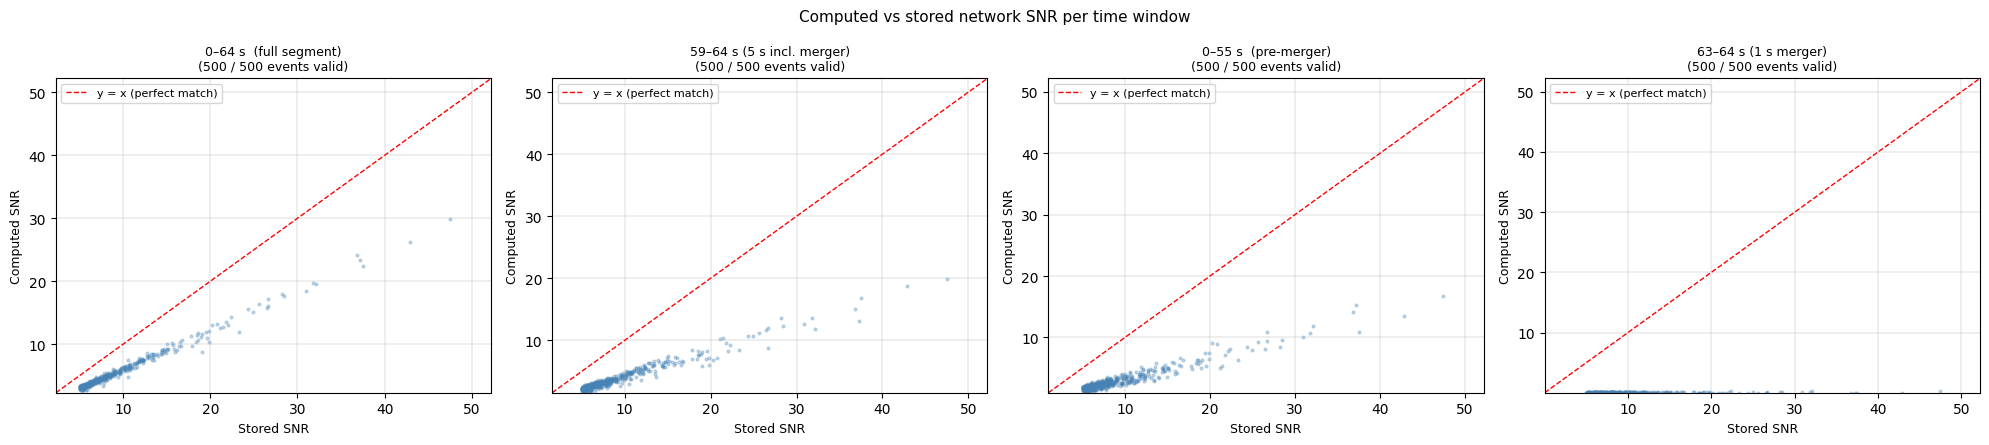

In [4]:
# ── Scatter: computed SNR vs stored SNR ──────────────────────────────────────
fig, axes = plt.subplots(1, len(WINDOWS), figsize=(5 * len(WINDOWS), 4.5))

for ax, (_, _, label) in zip(axes, WINDOWS):
    snr_computed, snr_stored = results[label]

    # Drop any events where SNR computation failed
    valid = np.isfinite(snr_computed) & np.isfinite(snr_stored)
    snr_c = snr_computed[valid]
    snr_s = snr_stored[valid]

    lo = min(snr_c.min(), snr_s.min()) * 0.9
    hi = max(snr_c.max(), snr_s.max()) * 1.1

    ax.scatter(snr_s, snr_c, s=4, alpha=0.3, color='steelblue', rasterized=True)
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1.0, label='y = x (perfect match)')
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel('Stored SNR', fontsize=9)
    ax.set_ylabel('Computed SNR', fontsize=9)
    ax.set_title(f"{label}\n({valid.sum()} / {len(valid)} events valid)", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, lw=0.3)

plt.suptitle('Computed vs stored network SNR per time window', fontsize=11)
plt.tight_layout()
plt.show()

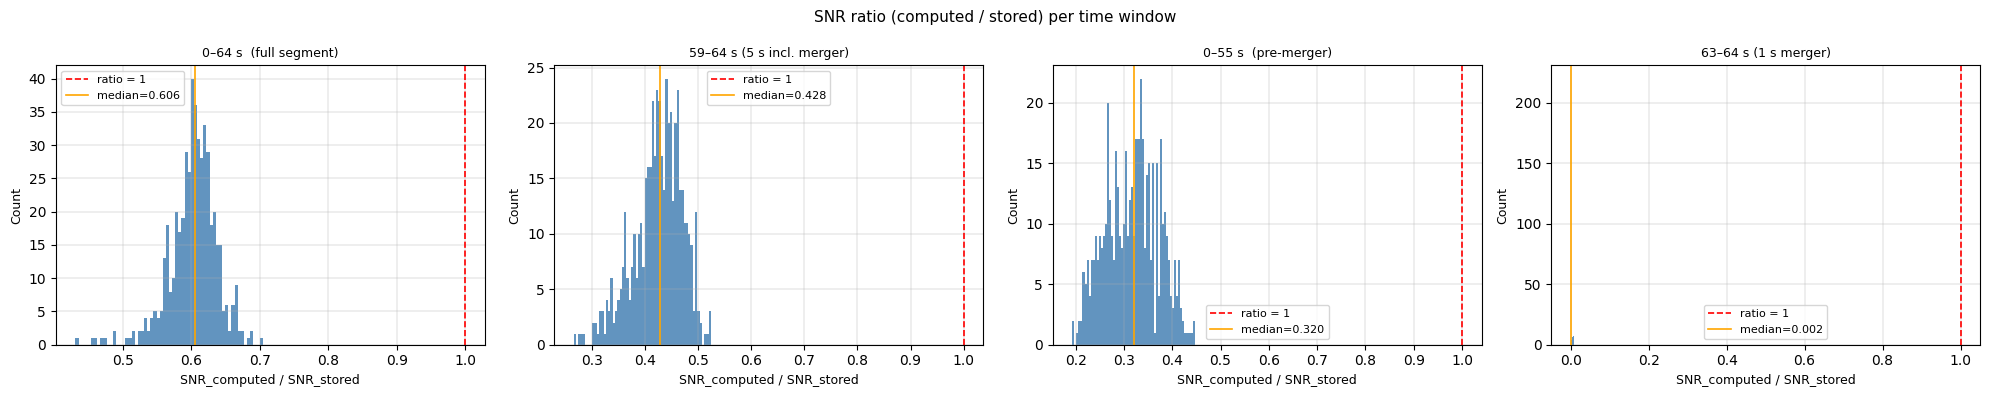

In [5]:
# ── Histogram: ratio (computed / stored) per window ──────────────────────────
fig, axes = plt.subplots(1, len(WINDOWS), figsize=(5 * len(WINDOWS), 4))

for ax, (_, _, label) in zip(axes, WINDOWS):
    snr_c, snr_s = results[label]
    ratio = snr_c / snr_s

    ax.hist(ratio, bins=60, color='steelblue', edgecolor='none', alpha=0.85)
    ax.axvline(1.0, color='red', lw=1.2, ls='--', label='ratio = 1')
    ax.axvline(np.median(ratio), color='orange', lw=1.2, ls='-',
               label=f'median={np.median(ratio):.3f}')
    ax.set_xlabel('SNR_computed / SNR_stored', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.set_title(label, fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, lw=0.3)

plt.suptitle('SNR ratio (computed / stored) per time window', fontsize=11)
plt.tight_layout()
plt.show()

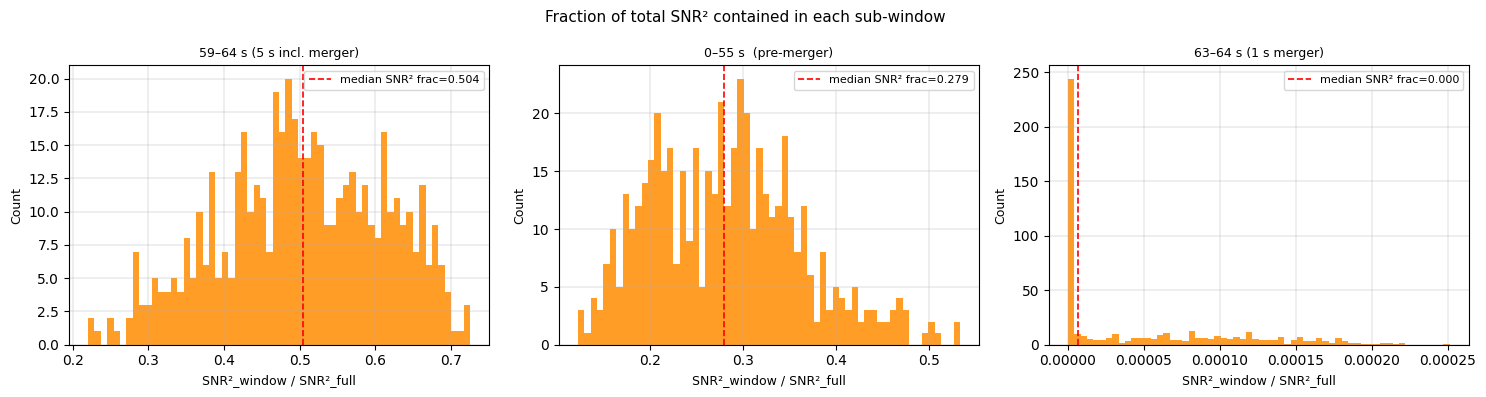

In [6]:
# ── SNR fraction: what fraction of total SNR is in each sub-window? ───────────
# Compare computed SNR in each sub-window to the full-segment computed SNR.
label_full = WINDOWS[0][2]  # "0–64 s (full segment)"
snr_full   = results[label_full][0]

fig, axes = plt.subplots(1, len(WINDOWS) - 1, figsize=(5 * (len(WINDOWS) - 1), 4))

for ax, (_, _, label) in zip(axes, WINDOWS[1:]):
    snr_c  = results[label][0]
    # SNR adds in quadrature, so fraction of SNR^2
    frac   = (snr_c / snr_full) ** 2

    ax.hist(frac, bins=60, color='darkorange', edgecolor='none', alpha=0.85)
    ax.axvline(np.median(frac), color='red', lw=1.2, ls='--',
               label=f'median SNR² frac={np.median(frac):.3f}')
    ax.set_xlabel('SNR²_window / SNR²_full', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.set_title(label, fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, lw=0.3)

plt.suptitle('Fraction of total SNR² contained in each sub-window', fontsize=11)
plt.tight_layout()
plt.show()